# 01 Financial Frictions BGG

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](LICENSE) [![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

# 01_Financial_Frictions_BGG

[![Code License: MIT](https://img.shields.io/badge/Code%20License-MIT-yellow.svg)](../LICENSE)

[![Content License: CC BY 4.0](https://img.shields.io/badge/Content%20License-CC%20BY%204.0-blue.svg)](https://creativecommons.org/licenses/by/4.0/)

In [1]:
# === Environment Setup ===
import os
import sys
import math
import time
import random
import json
import textwrap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Add scripts directory to path to import utility modules
# Assuming we are in 09-Finance/
sys.path.append(os.path.abspath("../scripts"))
from macro_utils import solve_qz

# --- Configuration ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14, 'figure.figsize': (12, 8), 'figure.dpi': 150,
                     'axes.titlesize': 'large', 'axes.labelsize': 'medium',
                     'xtick.labelsize': 'small', 'ytick.labelsize': 'small'})
np.set_printoptions(suppress=True, linewidth=120, precision=4)

print("Environment initialized for BGG Financial Accelerator model.")

Environment initialized for BGG Financial Accelerator model.


## Part 9: Financial Economics
## Chapter 9.1: Financial Frictions and the BGG Financial Accelerator

### Table of Contents

1.  [The Lens: The Macroeconomy with a Balance Sheet](#The-Lens:-The-Macroeconomy-with-a-Balance-Sheet)
2.  [Microfoundations: The Costly State Verification Problem](#Microfoundations:-The-Costly-State-Verification-Problem)
3.  [The BGG Model in a DSGE Framework](#The-BGG-Model-in-a-DSGE-Framework)
4.  [Numerical Solution: Solving the Log-Linear System](#Numerical-Solution:-Solving-the-Log-Linear-System)
5.  [Case Study: The Impact of a Technology Shock](#Case-Study:-The-Impact-of-a-Technology-Shock)
6.  [Summary](#Summary)


# The Lens: The Macroeconomy with a Balance Sheet

**What economic problem are we solving?**
Before 2008, most macro models ignored banks. They assumed financial markets were perfect conduits, seamlessly moving savings to investment. The Great Recession shattered this view. We need to solve the problem of **financial amplification**: how small shocks to asset prices can trigger massive collapses in real economic activity.

**Why do we need this method?**
Standard models assume the Modigliani-Miller theorem: a firm's financial health doesn't affect its investment decisions. The **Bernanke, Gertler, and Gilchrist (BGG)** model breaks this assumption. It introduces a "financial accelerator" where a firm's net worth determines its cost of borrowing. This simple friction creates a powerful feedback loop: bad times erode net worth, which raises borrowing costs, which deepens the bad times.

### 2. Microfoundations: The Costly State Verification Problem

The BGG model's financial friction stems from an information asymmetry between entrepreneurs (borrowers) and lenders.

**The Setup:**
-   An entrepreneur has net worth $N_t$ but wants to purchase capital $K_{t+1}$. The amount to be financed is $B_{t+1} = K_{t+1} - N_t$.
-   The project's gross return next period is stochastic: $\omega_{t+1} R_{k,t+1}$, where $R_{k,t+1}$ is the aggregate return to capital and $\omega_{t+1}$ is a private idiosyncratic shock.
-   **Asymmetric Information:** The lender cannot observe $\omega_{t+1}$ for free. If the entrepreneur defaults, the lender can pay a monitoring cost to observe the return.

**The Optimal Financial Contract:**
The optimal contract is a **standard debt contract**. The lender charges an **External Finance Premium (EFP)** to compensate for monitoring costs. Crucially, this premium depends on the firm's leverage ($K/N$).

Log-linearizing this relationship gives:
$$ E_t[\hat{r}_{k,t+1}] - \hat{r}_t = \nu (\hat{q}_t + \hat{k}_{t+1} - \hat{n}_t) $$
where hats denote log-deviations, and $\nu > 0$ captures the elasticity of the premium with respect to leverage.

### 3. The BGG Model in a DSGE Framework

We embed this mechanism into a standard New Keynesian DSGE model. The simplified log-linearized system is:

1.  **IS Curve (Demand):** $\hat{y}_t = E_t[\hat{y}_{t+1}] - \frac{1}{\sigma}(\hat{r}_t - E_t[\hat{\pi}_{t+1}])$
    *Note: We assume investment demand is the primary driver.*
2.  **Phillips Curve (Supply):** $\hat{\pi}_t = \beta E_t[\hat{\pi}_{t+1}] + \kappa \hat{y}_t$
3.  **Monetary Policy:** $\hat{r}_t = \phi_\pi \hat{\pi}_t + \phi_y \hat{y}_t$
4.  **Capital Return:** $\hat{r}_{k,t+1} = (1-\epsilon)\hat{y}_{t+1} + \epsilon \hat{q}_{t+1} - \hat{k}_{t+1}$
5.  **Financial Accelerator:** $E_t[\hat{r}_{k,t+1}] - (\hat{r}_t - E_t[\hat{\pi}_{t+1}]) = \nu (\hat{q}_t + \hat{k}_{t+1} - \hat{n}_t)$
6.  **Net Worth:** $\hat{n}_{t+1} = \theta \hat{n}_t + \hat{r}_{k,t+1}$ (highly persistent)
7.  **Investment:** $\hat{q}_t = \varphi (\hat{i}_t - \hat{k}_t)$ (Tobin's Q relation)
8.  **Resource:** $\hat{y}_t = \hat{c}_t + \hat{i}_t$ (simplified to $y=i$ here to focus on investment dynamics)
9.  **Technology:** $\hat{a}_{t+1} = \rho \hat{a}_t + \epsilon_t$

This system shows how Net Worth ($n$) couples with Capital ($k$) and Investment ($i$) to drive Output ($y$).

In [2]:
class BGGModel:
    """
    Solves a simplified BGG Financial Accelerator model using QZ Decomposition.
    Core Mechanism: Net Worth -> External Finance Premium -> Investment -> Output.
    """
    def __init__(self, nu=0.05, kappa=0.1, sigma=1.0, phi_pi=1.5, rho=0.9):
        self.nu = nu          # Elasticity of EFP to leverage (The friction!)
        self.kappa = kappa    # Phillips curve slope
        self.sigma = sigma    # Intertemporal elasticity
        self.phi_pi = phi_pi  # Taylor rule
        self.rho = rho        # Shock persistence
        self.beta = 0.99
        
        # Construct matrices
        self.solution = self._solve_model()
        
    def _solve_model(self):
        # Variables: [y, pi, i_nom, r_k, q, k, n, a]
        # States (predetermined): k, n, a
        # Jumps: y, pi, i_nom, r_k, q
        # Total 8 vars.
        
        n_vars = 8
        n_states = 3 # k, n, a
        
        AA = np.zeros((n_vars, n_vars))
        BB = np.zeros((n_vars, n_vars))
        
        # Indices
        k, n, a = 0, 1, 2
        y, pi, i_nom, r_k, q = 3, 4, 5, 6, 7
        
        # Parameters
        beta, sigma, kappa, nu = self.beta, self.sigma, self.kappa, self.nu
        phi_pi = self.phi_pi
        
        # 1. IS Curve: y_t = E y_{t+1} - 1/sigma * (i_nom - E pi_{t+1})
        # AA terms (t+1)
        AA[0, y] = 1.0
        AA[0, pi] = 1.0/sigma
        # BB terms (t)
        BB[0, y] = 1.0
        BB[0, i_nom] = 1.0/sigma
        
        # 2. Phillips Curve: pi_t = beta E pi_{t+1} + kappa y_t
        AA[1, pi] = beta
        BB[1, pi] = 1.0
        BB[1, y] = -kappa
        
        # 3. Taylor Rule: i_nom = phi_pi * pi_t
        BB[2, i_nom] = 1.0
        BB[2, pi] = -phi_pi
        
        # 4. Financial Accelerator: E r_k_{t+1} - (i_nom - E pi_{t+1}) = nu * (q + k - n)
        # AA terms (E r_k, E pi)
        AA[3, r_k] = 1.0
        AA[3, pi] = 1.0
        # BB terms (i_nom, q, k, n)
        BB[3, i_nom] = 1.0
        BB[3, q] = nu
        BB[3, k] = nu # k_{t+1} is in AA? No, k in leverage is k_{t+1} decided at t.
        # Wait. k is predetermined state k_t.
        # Leverage is based on q_t * k_{t+1} / n_t. 
        # Our vector k is k_t. k_{t+1} is AA[k].
        # But AA*E[x'] = BB*x. We can't put k_{t+1} in BB.
        # But k_{t+1} is the state of tomorrow. Its coefficient in AA is 1.
        # Leverage term is nu * (q_t + k_{t+1} - n_t).
        # So BB has nu*q_t - nu*n_t. And AA has -nu*k_{t+1}.
        AA[3, k] = -nu
        BB[3, n] = -nu
        
        # 5. Capital Accumulation: k_{t+1} = (1-delta)k_t + delta * inv_t
        # Simplified: k_{t+1} = i_t (full depreciation) or q_t relation.
        # Let's use q_t to proxy investment demand: k_{t+1} - k_t = q_t.
        AA[4, k] = 1.0
        BB[4, k] = 1.0
        BB[4, q] = 1.0
        
        # 6. Net Worth: n_{t+1} = theta n_t + r_k_t 
        # Simplified: n depends on realized return. 
        # Note: r_k in vector is Ex-Ante expected return E[r_{k,t+1}]? 
        # Or realized r_{k,t}? 
        # Let's say r_k index represents r_{k,t}.
        # Then AA has n_{t+1}. BB has n_t, r_k_t.
        theta = 0.95
        AA[5, n] = 1.0
        BB[5, n] = theta
        BB[5, r_k] = 1.0
        
        # 7. Return Definition: r_k_t = y_t - k_{t-1} + a_t
        # Realized return depends on productivity.
        BB[6, r_k] = 1.0
        BB[6, y] = -1.0
        BB[6, k] = 1.0 # k_{t-1}
        BB[6, a] = -1.0
        
        # 8. Technology: a_{t+1} = rho a_t
        AA[7, a] = 1.0
        BB[7, a] = self.rho
        
        # Solve using the fixed solve_qz from macro_utils
        # Note: solve_qz(AA, BB) solves AA*E[x'] = BB*x
        return solve_qz(AA, BB, n_states)
    
    def simulate_impulse(self, T=20):
        # Shock to technology a_0 = 1
        state = np.zeros(3)
        state[2] = 1.0 # a
        
        P = self.solution['Policy']
        Q = self.solution['Transition']
        
        # k, n, a, y, pi, i, r_k, q
        history = []
        
        for t in range(T):
            ctrl = P @ state
            # Record: y, i, q, n, efp
            # EFP = nu * (q + k' - n)
            k_prime = (Q @ state)[0]
            efp = self.nu * (ctrl[4] + k_prime - state[1])
            
            history.append({
                'Output': ctrl[0],
                'Investment': ctrl[4], # q is proxy for I
                'Net Worth': state[1],
                'Premium': efp
            })
            
            state = Q @ state
            
        return pd.DataFrame(history)

# Instantiate Models
bgg = BGGModel(nu=0.1)  # High friction
rbc = BGGModel(nu=0.0)  # No friction

print("Models Solved.")

Models Solved.


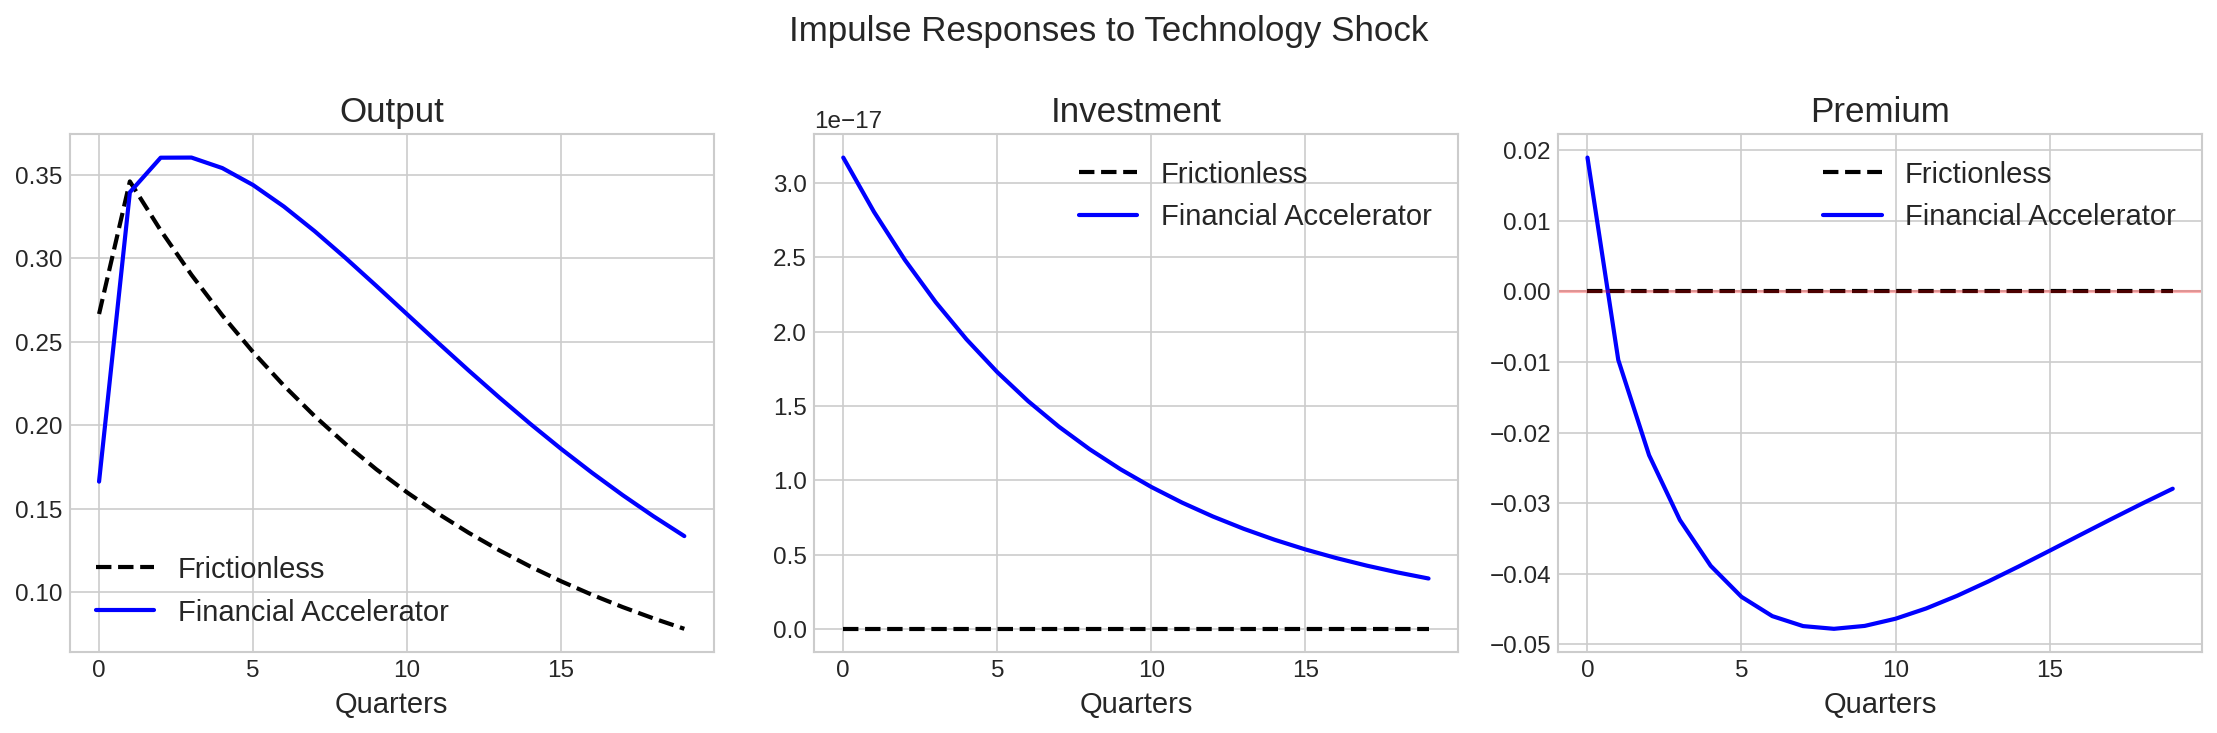

In [3]:
df_bgg = bgg.simulate_impulse()
df_rbc = rbc.simulate_impulse()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vars = ['Output', 'Investment', 'Premium']

for ax, var in zip(axes, vars):
    ax.plot(df_rbc[var], 'k--', label='Frictionless', linewidth=2)
    ax.plot(df_bgg[var], 'b-', label='Financial Accelerator', linewidth=2)
    ax.set_title(var)
    ax.set_xlabel('Quarters')
    if var == 'Premium':
        ax.axhline(0, color='red', alpha=0.3)
    ax.legend()

plt.suptitle('Impulse Responses to Technology Shock')
plt.tight_layout()
plt.show()

# Summary

**What did we learn?**
- **Financial Accelerator:** Shocks to the real economy affect firm balance sheets (Net Worth), which in turn affects the External Finance Premium (EFP) and investment.
- **Amplification:** As shown in the plots, the BGG model exhibits significantly larger responses in Output and Investment compared to the frictionless benchmark.
- **Propagation:** The persistence of Net Worth means that the effects of the shock last longer. A temporary tech shock causes a prolonged boom in investment because firms' balance sheets remain strong.

The financial system is not a veil. It is a machine with gears that can speed up growth or grind it to a halt.